<a href="https://colab.research.google.com/github/2303A52359/Explainable-AI/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries
import pandas as pd

# Load dataset
df = pd.read_csv("/content/World Population Growth.csv")

# Print full dataset
print("===== World Population Growth Dataset =====\n")
print(df.to_string())  # Prints all rows and columns

# Print dataset information
print("\n===== Dataset Information =====")
print(df.info())

# Print first 5 and last 5 rows
print("\n===== First 5 Rows =====")
print(df.head())

print("\n===== Last 5 Rows =====")
print(df.tail())

# Print summary statistics
print("\n===== Summary Statistics =====")
print(df.describe(include='all'))


===== World Population Growth Dataset =====

    Year     Population Yearly Growth %      Number  Density (Pop/km2)
0   1951  2,543,130,380           1.75%  43,808,223                 17
1   1952  2,590,270,899           1.85%  47,140,519                 17
2   1953  2,640,278,797           1.93%  50,007,898                 18
3   1954  2,691,979,339           1.96%  51,700,542                 18
4   1955  2,746,072,141           2.01%  54,092,802                 18
5   1956  2,801,002,631           2.00%  54,930,490                 19
6   1957  2,857,866,857           2.03%  56,864,226                 19
7   1958  2,916,108,097           2.04%  58,241,240                 20
8   1959  2,970,292,188           1.86%  54,184,091                 20
9   1960  3,019,233,434           1.65%  48,941,246                 20
10  1961  3,068,370,609           1.63%  49,137,175                 21
11  1962  3,126,686,743           1.90%  58,316,134                 21
12  1963  3,195,779,247         

Linear Regression

Mean Squared Error (MSE): 2398686211874905.5
R² Score: 0.9993112154033448
          Actual     Predicted
4   2.746072e+09  2.668859e+09
63  7.339013e+09  7.283252e+09
18  3.620655e+09  3.591995e+09
0   2.543130e+09  2.509606e+09
28  4.365583e+09  4.374183e+09
72  8.045311e+09  8.049758e+09
10  3.068371e+09  3.166366e+09
34  4.861731e+09  4.910168e+09
12  3.195779e+09  3.131238e+09
55  6.641416e+09  6.685590e+09


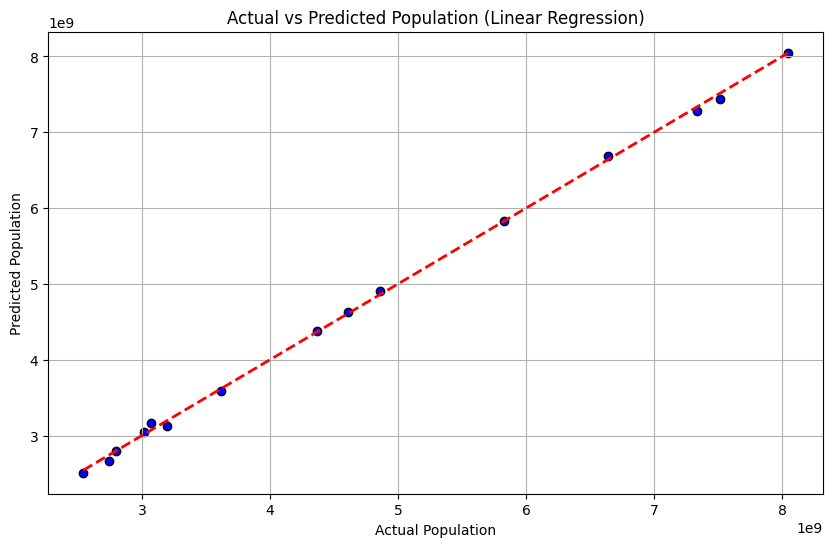

Predicted World Population in 2025: 8687908519.060974


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("/content/World Population Growth.csv")
df['Yearly Growth %'] = df['Yearly Growth %'].str.replace('%','').astype(float)
df['Population'] = df['Population'].replace(',', '', regex=True).astype(float)
df['Number'] = df['Number'].replace(',', '', regex=True).astype(float)
df['Density (Pop/km2)'] = df['Density (Pop/km2)'].replace(',', '', regex=True).astype(float)

X = df[['Year', 'Yearly Growth %', 'Number', 'Density (Pop/km2)']]
y = df['Population']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head(10))

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
plt.title("Actual vs Predicted Population (Linear Regression)")
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.grid(True)
plt.show()

future_data = pd.DataFrame({
    'Year': [2025],
    'Yearly Growth %': [0.88],
    'Number': [80000000],
    'Density (Pop/km2)': [60]
})
future_pred = model.predict(future_data)
print("Predicted World Population in 2025:", future_pred[0])

Svm

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = pd.read_csv("/content/World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.06666666666666667


Decision Tree

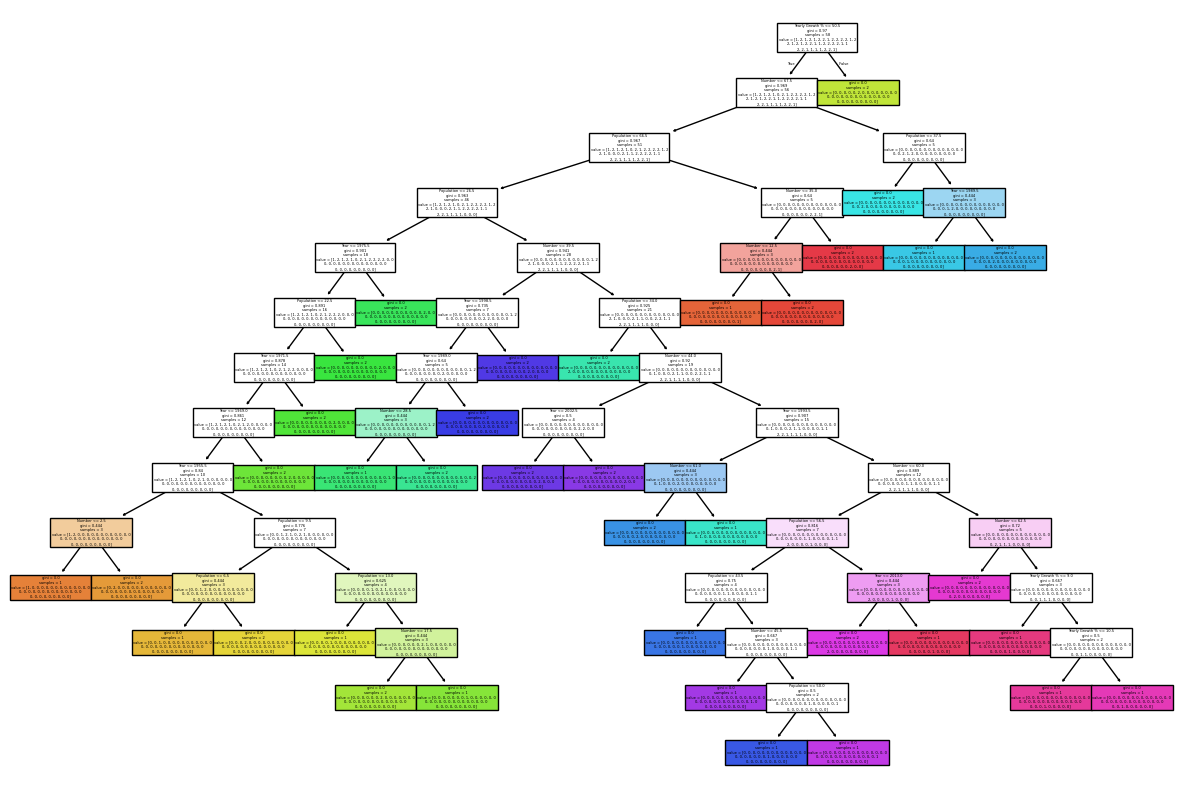

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = pd.read_csv("World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()


Random Forest

Accuracy: 0.5333333333333333


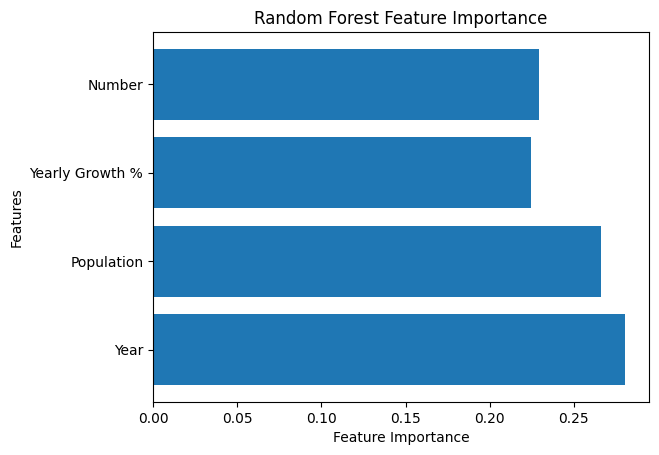

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = pd.read_csv("World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
importances = model.feature_importances_
plt.barh(X.columns, importances)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()


Xg Boost

Mean Squared Error (MSE): 0.33448949456214905
R² Score: 0.9978734254837036


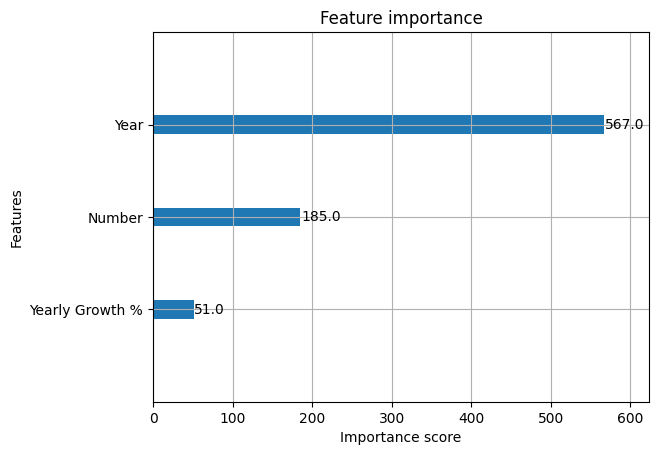

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

data = pd.read_csv("World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop('Density (Pop/km2)', axis=1)
y = data['Density (Pop/km2)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use XGBoost Regressor for predicting continuous values
model = XGBRegressor(objective='reg:squarederror') # Use a regression objective
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the regressor model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# Plot feature importance (optional for regression, but can still be informative)
plot_importance(model)
plt.show()

Ale

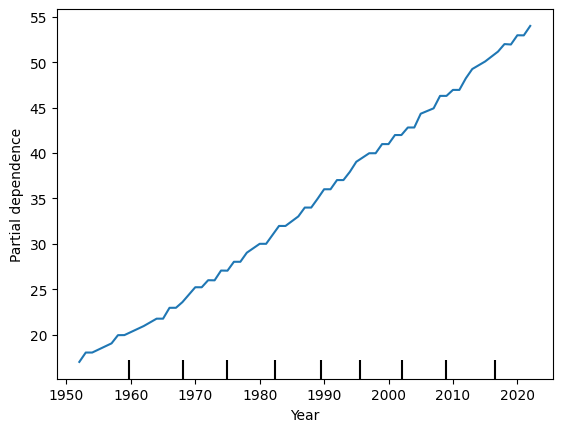

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

data = pd.read_csv("World Population Growth.csv")
data = data.dropna()
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col])
X = data.drop(data.columns[-1], axis=1)
y = data[data.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = XGBRegressor()
model.fit(X_train, y_train)
PartialDependenceDisplay.from_estimator(model, X_train, [0])
plt.show()


Permutations

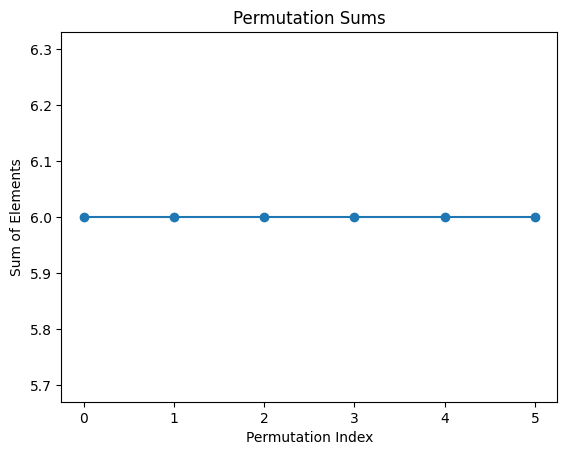

In [13]:
import itertools
import matplotlib.pyplot as plt

data = [1, 2, 3]
perms = list(itertools.permutations(data))
x = range(len(perms))
y = [sum(p) for p in perms]
plt.plot(x, y, marker='o')
plt.title("Permutation Sums")
plt.xlabel("Permutation Index")
plt.ylabel("Sum of Elements")
plt.show()
